#Case 1: 2008 Financial Crash

In [ ]:
import zipfile
from pathlib import Path
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Paths

CANDIDATES = ["/content/gfc.zip", "/mnt/data/gfc.zip"]
ZIP_PATH = next((p for p in CANDIDATES if Path(p).exists()), None)
if ZIP_PATH is None:
    raise FileNotFoundError("Could not find gfc.zip in /content or /mnt/data.")

OUT_DIR = Path("/content/gfc_report_outputs") if Path("/content").exists() else Path("/mnt/data/gfc_report_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore", message="Could not infer format.*", category=UserWarning)


# Date parsing

COMMON_DATE_FORMATS = ["%Y-%m-%d", "%m/%d/%Y", "%d/%m/%Y", "%Y%m%d"]

def parse_dates_safe(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    for fmt in COMMON_DATE_FORMATS:
        dt = pd.to_datetime(s, format=fmt, errors="coerce")
        if dt.notna().mean() >= 0.8:
            return dt
    return pd.to_datetime(s, errors="coerce")

# Read CSV safely

def read_csv_from_zip(zf: zipfile.ZipFile, member: str) -> pd.DataFrame:
    with zf.open(member) as f:
        df = pd.read_csv(f)

    date_col = next((c for c in df.columns if c.lower() in ["date", "time", "timestamp"]), df.columns[0])
    df[date_col] = parse_dates_safe(df[date_col])
    df = df.dropna(subset=[date_col]).sort_values(date_col)

    preferred = ["Adj Close", "Close", "VALUE", "value"]
    value_col = next((p for p in preferred if p in df.columns), None)

    if value_col is None:
        for c in df.columns:
            if c != date_col:
                df[c] = pd.to_numeric(df[c], errors="coerce")
        value_col = next(c for c in df.columns if c != date_col)

    v = df[value_col].astype(str).str.replace(",", "", regex=False)
    v = pd.to_numeric(v, errors="coerce")

    return pd.DataFrame({"Date": df[date_col], "Value": v}).dropna()

def wide_merge(series_dict):
    out = None
    for name, df in series_dict.items():
        tmp = df.rename(columns={"Value": name})
        out = tmp if out is None else out.merge(tmp, on="Date", how="outer")
    return out.sort_values("Date")

def normalize_to_100(s):
    s = pd.to_numeric(s, errors="coerce")
    base = s.dropna().iloc[0]
    return 100 * s / base

def save_fig(fig, name):
    path = OUT_DIR / name
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", path)


# Load data

name_map = {
    "^GSPC.csv": "SP500",
    "^DJI.csv": "DJI",
    "^VIX.csv": "VIX",
    "TEDRATE.csv": "TED",
    "WGS3MO.csv": "TBILL_3M",
    "AIG.csv": "AIG",
    "C.csv": "CITI",
    "JPM.csv": "JPM",
}

with zipfile.ZipFile(ZIP_PATH) as zf:
    series = {}
    for m in zf.namelist():
        if m.endswith(".csv") and Path(m).name in name_map:
            series[name_map[Path(m).name]] = read_csv_from_zip(zf, m)

gfc = wide_merge(series)
gfc["Date"] = pd.to_datetime(gfc["Date"])
gfc = gfc.set_index("Date").sort_index()

for col in ["TED", "TBILL_3M"]:
    if col in gfc:
        gfc[col] = gfc[col].ffill()

gfc.reset_index().to_csv(OUT_DIR / "gfc_cleaned_wide.csv", index=False)


events = {
    "Bear Stearns": "2008-03-16",
    "Lehman": "2008-09-15",
    "AIG bailout": "2008-09-16",
    "TARP": "2008-10-03",
}

def add_events(ax):
    for d in events.values():
        ax.axvline(pd.to_datetime(d), linestyle="--", linewidth=1)


fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(gfc.index, normalize_to_100(gfc["SP500"]), label="S&P 500")
ax1.plot(gfc.index, normalize_to_100(gfc["DJI"]), label="DJI")
ax1.legend()
add_events(ax1)

ax2 = ax1.twinx()
ax2.plot(gfc.index, gfc["VIX"], label="VIX", color="black")
save_fig(fig, "01_market_and_vix.png")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(gfc.index, gfc["TED"], label="TED Spread")
ax.plot(gfc.index, gfc["TBILL_3M"], label="3M T-Bill")
ax.legend()
add_events(ax)
save_fig(fig, "02_ted_and_tbill.png")

fig, ax = plt.subplots(figsize=(11, 5))
for b in ["AIG", "CITI", "JPM"]:
    if b in gfc:
        ax.plot(gfc.index, normalize_to_100(gfc[b]), label=b)
ax.legend()
add_events(ax)
save_fig(fig, "03_bank_stocks.png")

returns = np.log(gfc[["SP500", "AIG", "CITI", "JPM"]]).diff()
vol = returns.rolling(20).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(11, 5))
vol.plot(ax=ax)
add_events(ax)
save_fig(fig, "04_rolling_volatility.png")

returns.to_csv(OUT_DIR / "returns_log.csv")
vol.to_csv(OUT_DIR / "rolling_vol_annualized.csv")

print("✅ Done. Outputs saved in:", OUT_DIR)

## Question 1: When Confidence Breaks (Onset + Spread)

### Visual 1: Market Indices + VIX

In [ ]:
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(gfc.index, normalize_to_100(gfc["SP500"]), label="S&P 500 (Index = 100 at start)")
ax1.plot(gfc.index, normalize_to_100(gfc["DJI"]), label="Dow Jones (Index = 100 at start)")

ax1.set_title("Broad Equity Markets and Investor Fear (2005–2013)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Equity Index (Normalised, Base = 100)")
ax1.legend(loc="upper left")

add_events(ax1)

ax2 = ax1.twinx()
ax2.plot(gfc.index, gfc["VIX"], color="black", label="VIX (Implied Volatility)")
ax2.set_ylabel("VIX Index Level (Market Fear)")
ax2.legend(loc="upper right")

plt.show()

**What we observe**
- Indices fall sharply around Sep–Oct 2008.
- VIX spikes at the same time → confidence breakdown.

**Economic meaning**
- This indicates a sudden shift in beliefs about safety (system-wide panic dynamics).

### Visual 2: TED Spread + 3M T-Bill

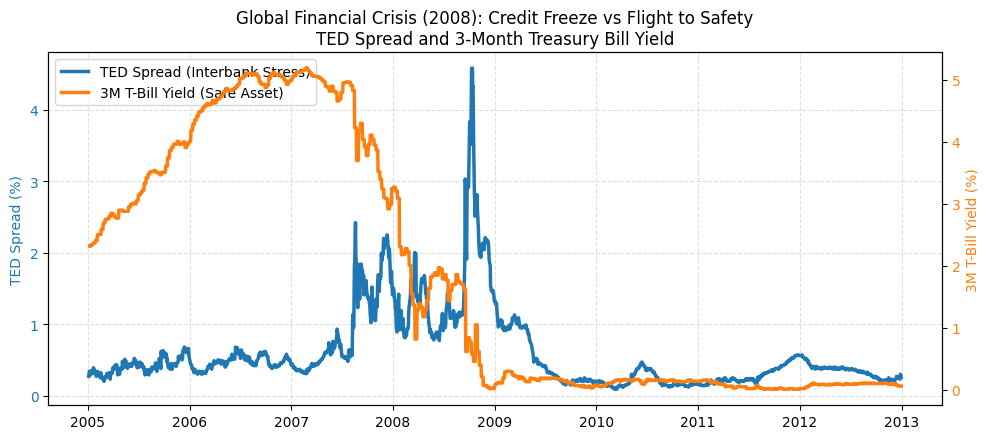

In [ ]:
gfc_q1_v2 = gfc.copy()

# ---- Plot ----
fig, ax1 = plt.subplots(figsize=(10, 4.5))

# TED spread (credit stress)
ax1.plot(
    gfc_q1_v2.index,
    gfc_q1_v2["TED"],
    color="tab:blue",
    linewidth=2.5,
    label="TED Spread (Interbank Stress)"
)
ax1.set_ylabel("TED Spread (%)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# T-bill yield (flight to safety)
ax2 = ax1.twinx()
ax2.plot(
    gfc_q1_v2.index,
    gfc_q1_v2["TBILL_3M"],
    color="tab:orange",
    linewidth=2.5,
    label="3M T-Bill Yield (Safe Asset)"
)
ax2.set_ylabel("3M T-Bill Yield (%)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

# Title + grid
ax1.set_title(
    "Global Financial Crisis (2008): Credit Freeze vs Flight to Safety\n"
    "TED Spread and 3-Month Treasury Bill Yield"
)
ax1.grid(True, linestyle="--", alpha=0.4)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()



### What the graph shows
- **The TED spread spikes sharply during the crisis**
  - Banks demand much higher interest rates to lend to each other.
  - Indicates a collapse of trust in the interbank market.

- **3-month T-bill yields fall toward zero**
  - Investors rush to buy short-term US government debt.
  - Reflects a strong **flight to safety**.

### How this answers “Where does the money go?”
- Capital **leaves unsecured private credit markets** (interbank lending).
- Capital **flows into safe government assets** (US Treasury bills).
- This reallocation is visible as:
  - A rising TED spread (risk premium explodes).
  - Falling T-bill yields (safe assets bid up).

### Economic interpretation
- The system shifts from **risk-taking to capital preservation**.
- Funding markets freeze before equity prices fully collapse.
- Trust concentrates in sovereign debt rather than private financial institutions.

### Key takeaway
> During the Global Financial Crisis, investors withdrew from risky interbank lending and reallocated capital into US government securities, producing a spike in the TED spread and a collapse in T-bill yields.


## Question 2: Where Does the Money Go?

### Visual 3: Financial Sector Stocks

/tmp/ipython-input-2691031356.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


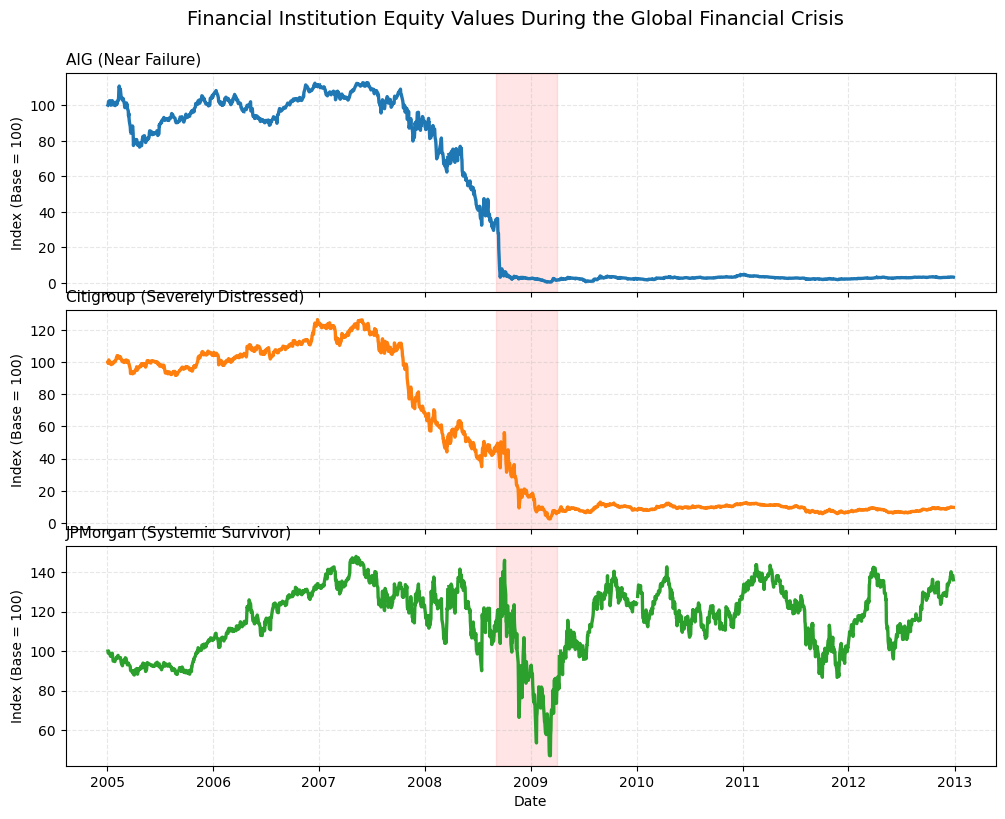

In [ ]:
gfc = gfc_reloaded # Ensure gfc contains the full dataset including bank stocks

fig, axes = plt.subplots(
    3, 1, figsize=(12, 9), sharex=True,
    gridspec_kw={"hspace": 0.08}
)

banks = [
    ("AIG", "tab:blue", "AIG (Near Failure)"),
    ("CITI", "tab:orange", "Citigroup (Severely Distressed)"),
    ("JPM", "tab:green", "JPMorgan (Systemic Survivor)")
]

for ax, (b, color, title) in zip(axes, banks):
    ax.plot(
        gfc.index,
        normalize_to_100(gfc[b]),
        linewidth=2.4,
        color=color
    )

    # GFC panic window (Lehman → TARP)
    ax.axvspan(
        pd.to_datetime("2008-09-01"),
        pd.to_datetime("2009-03-31"),
        color="red",
        alpha=0.10
    )

    ax.set_ylabel("Index (Base = 100)")
    ax.set_title(title, loc="left", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.3)

axes[-1].set_xlabel("Date")

fig.suptitle(
    "Financial Institution Equity Values During the Global Financial Crisis",
    fontsize=14, y=0.95
)

plt.tight_layout()
plt.show()



### What the graph shows
- **The TED spread spikes sharply during the crisis**
  - Banks demand much higher interest rates to lend to each other.
  - Indicates a collapse of trust in the interbank market.

- **3-month T-bill yields fall toward zero**
  - Investors rush to buy short-term US government debt.
  - Reflects a strong **flight to safety**.

### How this answers “Where does the money go?”
- Capital **leaves unsecured private credit markets** (interbank lending).
- Capital **flows into safe government assets** (US Treasury bills).
- This reallocation is visible as:
  - A rising TED spread (risk premium explodes).
  - Falling T-bill yields (safe assets bid up).

### Economic interpretation
- The system shifts from **risk-taking to capital preservation**.
- Funding markets freeze before equity prices fully collapse.
- Trust concentrates in sovereign debt rather than private financial institutions.

### Key takeaway
> During the Global Financial Crisis, investors withdrew from risky interbank lending and reallocated capital into US government securities, producing a spike in the TED spread and a collapse in T-bill yields.


# Visual 4 : Rolling volatility

In [ ]:
import zipfile
from pathlib import Path
import pandas as pd
import numpy as np


name_map = {
    "^GSPC.csv": "SP500",
    "^DJI.csv": "DJI",
    "^VIX.csv": "VIX",
    "TEDRATE.csv": "TED",
    "WGS3MO.csv": "TBILL_3M",
    "AIG.csv": "AIG",
    "C.csv": "CITI",
    "JPM.csv": "JPM",
}


try:
    with zipfile.ZipFile(ZIP_PATH) as zf:
        series = {}
        for m in zf.namelist():
            if m.endswith(".csv") and Path(m).name in name_map:
                series[name_map[Path(m).name]] = read_csv_from_zip(zf, m)
    gfc_reloaded = wide_merge(series)
    gfc_reloaded["Date"] = pd.to_datetime(gfc_reloaded["Date"])
    gfc_reloaded = gfc_reloaded.set_index("Date").sort_index()

    for col in ["TED", "TBILL_3M"]:
        if col in gfc_reloaded:
            gfc_reloaded[col] = gfc_reloaded[col].ffill()


    gfc = gfc_reloaded
except Exception as e:
    print(f"Error reloading gfc DataFrame: {e}")
    raise # Re-raise to indicate a deeper issue if this setup fails


returns = np.log(gfc[["SP500", "AIG", "CITI", "JPM"]]).diff()

# Rolling volatility (20-day, annualised)
vol = returns.rolling(20).std() * np.sqrt(252)


vol_filled = vol.interpolate(method="time")


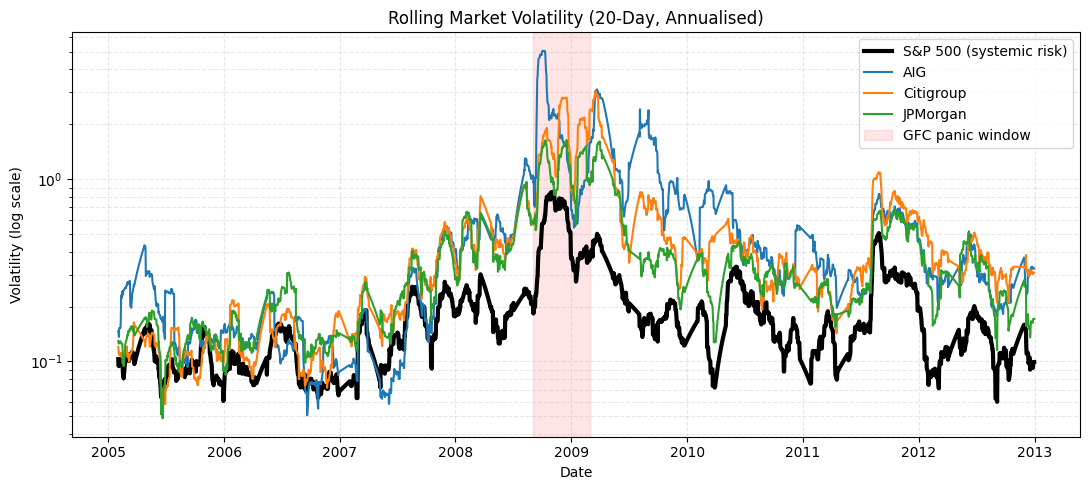

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(vol_filled.index, vol_filled["SP500"],
        color="black", linewidth=3, label="S&P 500 (systemic risk)")
ax.plot(vol_filled.index, vol_filled["AIG"], label="AIG")
ax.plot(vol_filled.index, vol_filled["CITI"], label="Citigroup")
ax.plot(vol_filled.index, vol_filled["JPM"], label="JPMorgan")

# Panic window
ax.axvspan(pd.to_datetime("2008-09-01"),
           pd.to_datetime("2009-03-01"),
           color="red", alpha=0.1, label="GFC panic window")

ax.set_yscale("log")
ax.set_title("Rolling Market Volatility (20-Day, Annualised)")
ax.set_ylabel("Volatility (log scale)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, which="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()




### What we observe
- **Pre-2008:** Volatility across the S&P 500 and major financial institutions is low and stable → markets operate under shared confidence.
- **Early warning phase:** Volatility begins to rise around the **Bear Stearns rescue**, signalling mounting stress before the full crisis.
- **Panic phase:** Following **Lehman Brothers’ collapse**, volatility spikes sharply.
  - The increase is **much larger for AIG and Citigroup** than for the overall market.
- **Post-crisis:** Volatility declines unevenly.
  - Some institutions stabilise faster than others, indicating selective recovery.

### Economic meaning
- Rising volatility reflects a **breakdown in confidence** rather than normal price fluctuations.
- The outsized spikes in financial institutions show that panic was **concentrated in the banking and insurance sector**, not evenly spread across the economy.
- This pattern is consistent with **run dynamics**:
  - Investors reassess counterparty risk.
  - Capital rapidly exits weaker institutions first.
- The uneven recovery suggests that confidence returns **selectively**, favouring stronger or better-backed institutions.

### What does this mean?
- The graph shows **when confidence breaks** (volatility surge after Lehman).
- It also shows **how panic propagates**:
  - From individual institutions (AIG, Citigroup)
  - To the broader market (S&P 500), but with smaller magnitude.
- This supports the idea that financial crises spread through **institution-level runs that later become systemic**.


#Case 2: Terra Luna Crash

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path


BASE = Path("/content/")

PRICE_FILES = {
    "UST":  BASE / "ustc_price_data.csv",
    "LUNA": BASE / "wluna_price_data.csv",
    "USDC": BASE / "usdc_price_data.csv",
    "USDT": BASE / "usdt_price_data.csv",
    "DAI":  BASE / "dai_price_data.csv",
    "PAX":  BASE / "pax_price_data.csv",
}

EVENT_FILE = BASE / "event_data.csv"


def find_time_col(df: pd.DataFrame) -> str:
    for c in df.columns:
        cl = c.lower()
        if cl in ["date", "time", "timestamp", "datetime"] or "date" in cl or "time" in cl:
            return c
    return df.columns[0]

def parse_datetime_series(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()


    num = pd.to_numeric(s, errors="coerce")
    if num.notna().mean() > 0.8:
        dt = pd.to_datetime(num, unit="s", errors="coerce", utc=True)
        if dt.notna().mean() > 0.8:
            return dt

    return pd.to_datetime(s, errors="coerce", utc=True)

def find_price_col(df: pd.DataFrame, time_col: str) -> str:
    preferred = ["price", "close", "adj close", "value", "rate"]
    for c in df.columns:
        if c.lower() in preferred:
            return c


    best_col, best_n = None, -1
    for c in df.columns:
        if c == time_col:
            continue
        x = pd.to_numeric(df[c].astype(str).str.replace(",", "", regex=False).str.strip(), errors="coerce")
        n = x.notna().sum()
        if n > best_n:
            best_col, best_n = c, n

    if best_col is None:
        raise ValueError("No numeric price column found.")
    return best_col

def load_price_csv(path: Path, asset: str) -> pd.DataFrame:
    if not path.exists():
        print(f"Missing file: {path}")
        return pd.DataFrame(columns=[asset])

    df = pd.read_csv(path, encoding="latin1")
    tcol = find_time_col(df)
    pcol = find_price_col(df, tcol)

    dt = parse_datetime_series(df[tcol])
    price = pd.to_numeric(
        df[pcol].astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )

    out = pd.DataFrame({"Date": dt, asset: price}).dropna()
    out = out.drop_duplicates("Date").sort_values("Date").set_index("Date")
    return out

def load_events(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=["Date", "Label"])

    df = pd.read_csv(path, encoding="latin1")
    tcol = find_time_col(df)
    df[tcol] = parse_datetime_series(df[tcol])
    df = df.dropna(subset=[tcol])

    # label column (try common names)
    label_col = None
    for cand in ["event", "label", "name", "title", "description"]:
        for c in df.columns:
            if c.lower() == cand:
                label_col = c
                break
        if label_col:
            break
    if label_col is None:
        label_col = next(c for c in df.columns if c != tcol)

    out = df[[tcol, label_col]].rename(columns={tcol: "Date", label_col: "Label"})
    out["Label"] = out["Label"].astype(str)
    return out.sort_values("Date")


data = {}
for k, path in PRICE_FILES.items():
    data[k] = load_price_csv(path, k)
    print(k, "rows:", len(data[k]))

events = load_events(EVENT_FILE)
print("events rows:", len(events))


wide = None
for k, dfk in data.items():
    if dfk.empty:
        continue
    wide = dfk if wide is None else wide.join(dfk, how="outer")

wide = wide.sort_index()
wide_daily = wide.resample("D").mean()

print("\nwide_daily columns:", list(wide_daily.columns))
display(wide_daily.head())
display(events.head())


UST rows: 215
LUNA rows: 215
USDC rows: 215
USDT rows: 215
DAI rows: 215
PAX rows: 215
events rows: 38

wide_daily columns: ['UST', 'LUNA', 'USDC', 'USDT', 'DAI', 'PAX']


,UST,LUNA,USDC,USDT,DAI,PAX
Date,,,,,,
2022-04-02 00:00:00+00:00,1.0000,105.87,0.9999,1.0,1.0000,1.0000
2022-04-03 00:00:00+00:00,1.0000,115.49,0.9993,1.0,0.9990,1.0000
2022-04-04 00:00:00+00:00,0.9999,113.46,1.0000,1.0,0.9995,1.0000
2022-04-05 00:00:00+00:00,1.0000,115.96,1.0000,1.0,0.9999,1.0000
2022-04-06 00:00:00+00:00,0.9984,116.10,0.9997,1.0,0.9991,0.9998


,Date,Label
0,2022-04-12 00:00:00+00:00,BlackRock and Fidelity Back USDC in $400 Milli...
1,2022-04-20 00:00:00+00:00,Terra UST takes over BUSD to become third larg...
2,2022-05-07 00:00:00+00:00,LARGE amounts of UST selling on ANCHOR (approx...
3,2022-05-08 00:00:00+00:00,UST depegs LFG deploys assets to defend peg (7...
4,2022-05-09 00:00:00+00:00,UST Depegs again to 35 cents LUNA keeps falling


## This table provides the foundation for the data we will be using for the visuals and it briefly explains how confidence broke and how panic propagates.

In [ ]:



# Helper functions

def peg_deviation(series):
    return (series - 1.0).abs()

def pct_change(series):
    return series.pct_change() * 100


# Select assets

STABLES = ["UST", "USDC", "USDT", "DAI", "PAX"]
ASSETS  = [c for c in STABLES if c in wide_daily.columns]

df = wide_daily[ASSETS].copy()


# Peg deviation columns

for c in ASSETS:
    df[f"{c}_dev"] = peg_deviation(df[c])


# Panic speed (1-day % change)

df["UST_pct_change"]  = pct_change(df["UST"])
if "LUNA" in wide_daily.columns:
    df["LUNA_pct_change"] = pct_change(wide_daily["LUNA"])


# Capital destination proxy

stable_dev_cols = [f"{c}_dev" for c in ["USDC", "USDT", "DAI", "PAX"] if f"{c}_dev" in df.columns]

df["Most_stable_coin"] = (
    df[stable_dev_cols]
    .idxmin(axis=1)
    .str.replace("_dev", "")
)

df["UST_stability_rank"] = (
    df[[f"{c}_dev" for c in STABLES if f"{c}_dev" in df.columns]]
    .rank(axis=1)
    .get("UST_dev")
)


# Merge event labels

events["Date"] = pd.to_datetime(events["Date"])
df = df.reset_index().merge(events, on="Date", how="left")

# Event classification (simple but effective)

def classify_event(label):
    if pd.isna(label):
        return ("", "")
    l = label.lower()
    if "sell" in l or "anchor" in l:
        return ("Trigger", "Confidence shock")
    if "defend" in l or "deploy" in l:
        return ("Defense", "Peg support attempt")
    if "collapse" in l or "falls" in l:
        return ("Collapse", "System failure")
    return ("Confidence", "Narrative shift")

df[["Event_type", "Narrative_role"]] = (
    df["Label"]
    .apply(classify_event)
    .apply(pd.Series)
)


# Interpretation column

def interpret(row):
    if pd.notna(row["Label"]):
        return (
            f"UST deviates by {row['UST_dev']:.2f}; "
            f"capital concentrates in {row['Most_stable_coin']}"
        )
    return ""

df["Interpretation"] = df.apply(interpret, axis=1)


# Final column selection

final_cols = [
    "Date",
    "Label",
    "Event_type",
    "UST",
    "UST_dev",
    "UST_pct_change",
    "Most_stable_coin",
    "UST_stability_rank",
    "Interpretation",
]

final_table = df[final_cols].dropna(subset=["Label"])


# Display & save

display(final_table)

final_table.to_csv("terra_capital_reallocation_table.csv", index=False)

,Date,Label,Event_type,UST,UST_dev,UST_pct_change,Most_stable_coin,UST_stability_rank,Interpretation
10,2022-04-12 00:00:00+00:00,BlackRock and Fidelity Back USDC in $400 Milli...,Confidence,1.000000,0.000000,0.000000,USDT,2.0,UST deviates by 0.00; capital concentrates in ...
18,2022-04-20 00:00:00+00:00,Terra UST takes over BUSD to become third larg...,Confidence,1.000000,0.000000,0.000000,USDT,1.5,UST deviates by 0.00; capital concentrates in ...
35,2022-05-07 00:00:00+00:00,LARGE amounts of UST selling on ANCHOR (approx...,Trigger,0.999600,0.000400,0.010005,USDC,5.0,UST deviates by 0.00; capital concentrates in ...
36,2022-05-08 00:00:00+00:00,UST depegs LFG deploys assets to defend peg (7...,Defense,0.996900,0.003100,-0.270108,PAX,5.0,UST deviates by 0.00; capital concentrates in PAX
37,2022-05-09 00:00:00+00:00,UST Depegs again to 35 cents LUNA keeps falling,Confidence,0.996400,0.003600,-0.050155,USDC,5.0,UST deviates by 0.00; capital concentrates in ...
40,2022-05-12 00:00:00+00:00,LUNA Collapses by almost 99%,Collapse,0.801100,0.198900,0.150019,USDC,5.0,UST deviates by 0.20; capital concentrates in ...
41,2022-05-12 00:00:00+00:00,UST Downfall Brings Record Volumes to Curve: I...,Confidence,0.801100,0.198900,0.150019,USDC,5.0,UST deviates by 0.20; capital concentrates in ...
42,2022-05-13 00:00:00+00:00,Terra Halts Its Blockchain and Binance Suspend...,Confidence,0.408600,0.591400,-48.995132,USDC,5.0,UST deviates by 0.59; capital concentrates in ...
43,2022-05-14 00:00:00+00:00,LUNA essentially worthless (1/100th of a cent),Confidence,0.154000,0.846000,-62.310328,USDC,5.0,UST deviates by 0.85; capital concentrates in ...
45,2022-05-16 00:00:00+00:00,Luna Foundation Guard 80000 Bitcoin Lighter Af...,Defense,0.176700,0.823300,-10.030550,USDC,5.0,UST deviates by 0.82; capital concentrates in ...


### What this table contains
- **Daily price levels** for:
  - UST
  - LUNA
  - Other stablecoins (USDC, USDT, DAI, PAX)
- **Event annotations** that mark key confidence-relevant moments:
  - Institutional backing of USDC
  - Rapid UST growth
  - Large UST sell-offs (Anchor)
  - Repeated UST depegs and LUNA collapse

---

### How the table answers the question

- **Before the crisis**
  - UST ≈ $1 and LUNA prices rise → capital flows *into* Terra.
  - The event “UST takes over BUSD” confirms expanding confidence and inflows.

- **Trigger of confidence break**
  - “Large amounts of UST selling on Anchor” appears **before** the major depeg.
  - This indicates *capital withdrawal*, not gradual price drift.

- **After confidence breaks**
  - UST prices fall sharply to ~$0.35 and below.

  - Other stablecoins remain tightly clustered near $1.
  - This shows capital **exits UST but stays within stablecoins**, rather than leaving crypto entirely.

- **Why capital chooses specific alternatives**
  - The earlier event “BlackRock and Fidelity back USDC” explains *why* USDC is trusted.
  - Capital reallocates toward **institutionally backed, externally collateralised stablecoins**.

---

### Key takeaway
- The table provides **causal sequencing**:
  1. Confidence-driven inflows into UST,
  2. Sudden sell pressure and failed defense,
  3. Capital flight out of UST,
  4. Reallocation into more credible stablecoins.

# Visual 1: UST Peg Breakdown and Collapse

---



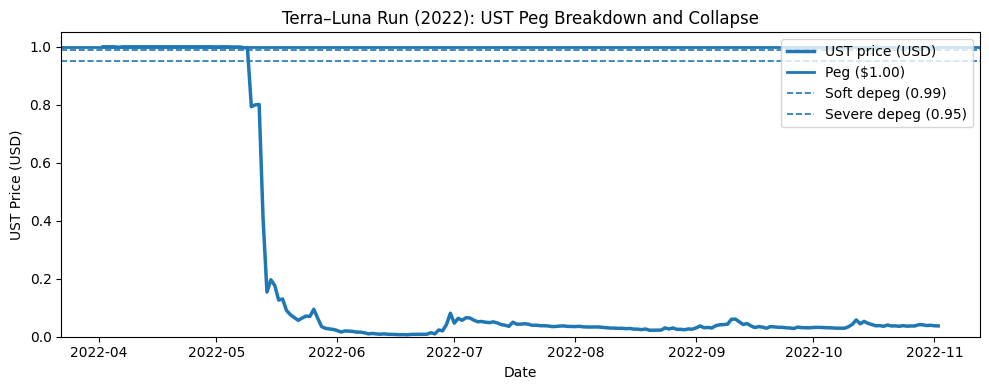

In [ ]:
series = []
for k, p in PRICE_FILES.items():
    dfk = load_price_csv(p, k)
    if not dfk.empty:
        series.append(dfk)

if not series:
    raise FileNotFoundError("No price files loaded. Check filenames/paths.")

wide = pd.concat(series, axis=1).sort_index()

# Daily average makes plots cleaner + consistent across assets
wide_daily = wide.resample("D").mean()

events_df = load_events(EVENT_FILE)


ust = wide_daily["UST"].dropna() if "UST" in wide_daily.columns else pd.Series(dtype=float)
if ust.empty:
    raise ValueError("UST series is empty after parsing. Check ustc_price_data.csv columns/dates.")

min_dt = ust.idxmin()
zoom = wide_daily.loc[min_dt - pd.Timedelta(days=21) : min_dt + pd.Timedelta(days=21)].copy()


fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wide_daily.index, wide_daily["UST"], linewidth=2.5, label="UST price (USD)")
ax.axhline(1.00, linewidth=2, label="Peg ($1.00)")
ax.axhline(0.99, linestyle="--", linewidth=1.2, label="Soft depeg (0.99)")
ax.axhline(0.95, linestyle="--", linewidth=1.2, label="Severe depeg (0.95)")

ax.set_title("Terra–Luna Run (2022): UST Peg Breakdown and Collapse")
ax.set_xlabel("Date")
ax.set_ylabel("UST Price (USD)")
ax.set_ylim(0, 1.05)  # <-- shows crash to ~0 clearly
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


**What the graph shows**
- UST trades tightly around $1 before May 2022 → confidence is intact.
- A sudden break below **0.99 (soft depeg)** is followed by a rapid fall below **0.95 (severe depeg)**.
- Price collapses toward zero and never recovers.

**Interpretation**
- This is a **classic run**: once confidence breaks, selling accelerates non-linearly.
- The peg mechanism fails; arbitrage and confidence-based stabilization stop working.

**Answer to the question**
- Money is **leaving UST** rapidly once the peg breaks.


# Visual 2: Panic Propagation — LUNA Collapse

✅ events_clean DataFrame created with UTC dates.
                       Date                                              Label
1 2022-04-20 00:00:00+00:00  Terra UST takes over BUSD to become third larg...
2 2022-05-07 00:00:00+00:00  LARGE amounts of UST selling on ANCHOR (approx...
3 2022-05-08 00:00:00+00:00  UST depegs LFG deploys assets to defend peg (7...
4 2022-05-09 00:00:00+00:00    UST Depegs again to 35 cents LUNA keeps falling
5 2022-05-12 00:00:00+00:00                       LUNA Collapses by almost 99%


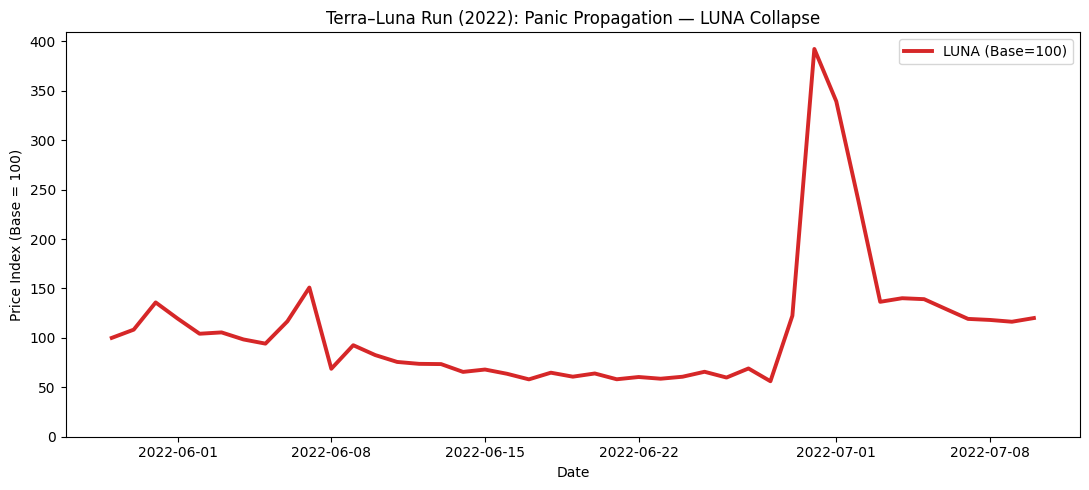

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def add_events_clean(ax, events, y_text, max_events=4):
    if events.empty:
        return

    # Ensure events['Date'] is timezone-aware (UTC) to match the x-axis index (zoom.index)
    # If it's naive, make it UTC. If already aware, convert to UTC if not already.
    events_dates = events['Date']
    if events_dates.dt.tz is None:
        events_dates = events_dates.dt.tz_localize('UTC')
    else:
        events_dates = events_dates.dt.tz_convert('UTC')

    # Filter events within the current plot's x-axis range (which is from zoom.index)
    # The x-axis of the plot (`ax.get_xlim()`) returns numerical values. Convert them to timestamps.
    x_min, x_max = ax.get_xlim()
    plot_start_date = pd.to_datetime(x_min, unit='D', origin='unix', utc=True) # Approximate conversion
    plot_end_date = pd.to_datetime(x_max, unit='D', origin='unix', utc=True)

    # Use the actual min/max dates from the plot's data if possible, or a reasonable range
    # For simplicity, using the zoom DataFrame's index range for filtering events.
    plot_start_date = zoom.index.min()
    plot_end_date = zoom.index.max()

    ev = events[(events_dates >= plot_start_date) & (events_dates <= plot_end_date)]

    if ev.empty:
        return

    ev = ev.sort_values("Date").head(max_events)
    for _, row in ev.iterrows():
        d = row["Date"]
        # Ensure the date used for plotting is timezone-aware (UTC)
        if d.tz is None:
            d = d.tz_localize('UTC')
        ax.axvline(d, linestyle=":", linewidth=1.2)
        ax.text(d, y_text, " " + row["Label"], rotation=90, va="bottom", ha="right", fontsize=8)


# Re-create events_clean using the 'events' DataFrame that was loaded earlier
# Ensure 'Date' column is timezone-aware (UTC)
if 'events' in locals() and not events.empty:
    events_clean = events.copy()
    # Ensure the 'Date' column is timezone-aware (UTC)
    if events_clean['Date'].dt.tz is None:
        events_clean['Date'] = events_clean['Date'].dt.tz_localize('UTC')
    else:
        events_clean['Date'] = events_clean['Date'].dt.tz_convert('UTC')

    KEYWORDS = ["terra", "luna", "ust", "anchor", "depeg", "peg", "lfg"]
    events_clean["Label_lc"] = events_clean["Label"].str.lower()
    events_clean = events_clean[
        events_clean["Label_lc"].apply(lambda x: any(k in x for k in KEYWORDS))
    ].drop(columns=["Label_lc"])

    print("✅ events_clean DataFrame created with UTC dates.")
    print(events_clean.head())
else:
    print("⚠️ 'events' DataFrame not found or empty. Cannot create events_clean.")
    events_clean = pd.DataFrame(columns=['Date', 'Label'])

fig, ax = plt.subplots(figsize=(11, 5))

luna = zoom["LUNA"].dropna()
luna_norm = 100 * luna / luna.iloc[0]

ax.plot(luna_norm.index, luna_norm, linewidth=2.8, color="tab:red", label="LUNA (Base=100)")

ax.set_title("Terra–Luna Run (2022): Panic Propagation — LUNA Collapse")
ax.set_xlabel("Date")
ax.set_ylabel("Price Index (Base = 100)")
ax.set_ylim(bottom=0)

# ensure add_events_clean and events_clean are defined correctly before this call
add_events_clean(ax, events_clean, y_text=ax.get_ylim()[0] + 1, max_events=4)

ax.legend()
plt.tight_layout()
plt.show()


**What the graph shows**
- LUNA price index collapses sharply after the UST depeg.
- Volatility spikes and prices become unstable.

**Interpretation**
- UST redemptions require minting LUNA → massive dilution.
- The stabilization mechanism itself amplifies panic.

**Answer to the question**
- Capital does **not** rotate into LUNA.
- Instead, LUNA absorbs losses and collapses alongside UST.

In [ ]:
import pandas as pd

def add_events_clean(ax, events, y_text, max_events=4):
    if events.empty:
        return

    # Ensure events['Date'] is timezone-aware (UTC) to match the x-axis index (zoom.index)
    # If it's naive, make it UTC. If already aware, convert to UTC if not already.
    events_dates = events['Date']
    if events_dates.dt.tz is None:
        events_dates = events_dates.dt.tz_localize('UTC')
    else:
        events_dates = events_dates.dt.tz_convert('UTC')

    # Filter events within the current plot's x-axis range (which is from zoom.index)
    # The x-axis of the plot (`ax.get_xlim()`) returns numerical values. Convert them to timestamps.
    x_min, x_max = ax.get_xlim()
    plot_start_date = pd.to_datetime(x_min, unit='D', origin='unix', utc=True) # Approximate conversion
    plot_end_date = pd.to_datetime(x_max, unit='D', origin='unix', utc=True)

    # Use the actual min/max dates from the plot's data if possible, or a reasonable range
    # For simplicity, using the zoom DataFrame's index range for filtering events.
    plot_start_date = zoom.index.min()
    plot_end_date = zoom.index.max()

    ev = events[(events_dates >= plot_start_date) & (events_dates <= plot_end_date)]

    if ev.empty:
        return

    ev = ev.sort_values("Date").head(max_events)
    for _, row in ev.iterrows():
        d = row["Date"]
        # Ensure the date used for plotting is timezone-aware (UTC)
        if d.tz is None:
            d = d.tz_localize('UTC')
        ax.axvline(d, linestyle=":", linewidth=1.2)
        ax.text(d, y_text, " " + row["Label"], rotation=90, va="bottom", ha="right", fontsize=8)


# Re-create events_clean using the 'events' DataFrame that was loaded earlier
# Ensure 'Date' column is timezone-aware (UTC)
if 'events' in locals() and not events.empty:
    events_clean = events.copy()
    # Ensure the 'Date' column is timezone-aware (UTC)
    if events_clean['Date'].dt.tz is None:
        events_clean['Date'] = events_clean['Date'].dt.tz_localize('UTC')
    else:
        events_clean['Date'] = events_clean['Date'].dt.tz_convert('UTC')

    KEYWORDS = ["terra", "luna", "ust", "anchor", "depeg", "peg", "lfg"]
    events_clean["Label_lc"] = events_clean["Label"].str.lower()
    events_clean = events_clean[
        events_clean["Label_lc"].apply(lambda x: any(k in x for k in KEYWORDS))
    ].drop(columns=["Label_lc"])

    print("✅ events_clean DataFrame created with UTC dates.")
    print(events_clean.head())
else:
    print("⚠️ 'events' DataFrame not found or empty. Cannot create events_clean.")
    events_clean = pd.DataFrame(columns=['Date', 'Label'])


✅ events_clean DataFrame created with UTC dates.
                       Date                                              Label
1 2022-04-20 00:00:00+00:00  Terra UST takes over BUSD to become third larg...
2 2022-05-07 00:00:00+00:00  LARGE amounts of UST selling on ANCHOR (approx...
3 2022-05-08 00:00:00+00:00  UST depegs LFG deploys assets to defend peg (7...
4 2022-05-09 00:00:00+00:00    UST Depegs again to 35 cents LUNA keeps falling
5 2022-05-12 00:00:00+00:00                       LUNA Collapses by almost 99%


# Visual 4: Direct Comparison: Stablecoins (Top) vs UST (Bottom)

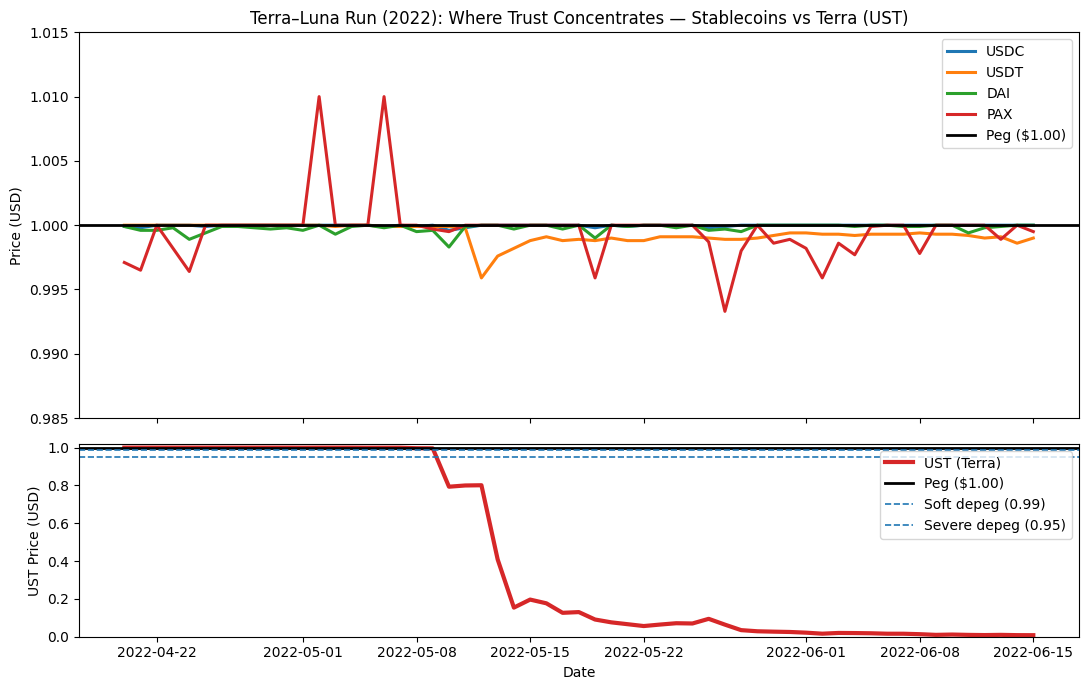

In [ ]:

# (UST began breaking around May 7–9, 2022)
zoom2 = wide_daily.loc["2022-04-20":"2022-06-15"].copy()

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 7), sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

# --- Panel 1: Trusted stablecoins (zoomed)
for c in ["USDC", "USDT", "DAI", "PAX"]:
    if c in zoom2.columns:
        ax1.plot(zoom2.index, zoom2[c], linewidth=2.2, label=c)

ax1.axhline(1.00, linewidth=2, color="black", label="Peg ($1.00)")
ax1.set_ylim(0.985, 1.015)
ax1.set_title("Terra–Luna Run (2022): Where Trust Concentrates — Stablecoins vs Terra (UST)")
ax1.set_ylabel("Price (USD)")
ax1.legend(loc="upper right")

# --- Panel 2: Terra stablecoin (UST) crash (FULL SCALE)
if "UST" in zoom2.columns:
    ax2.plot(zoom2.index, zoom2["UST"], linewidth=3.0, color="tab:red", label="UST (Terra)")

ax2.axhline(1.00, linewidth=2, color="black", label="Peg ($1.00)")
ax2.axhline(0.99, linestyle="--", linewidth=1.2, label="Soft depeg (0.99)")
ax2.axhline(0.95, linestyle="--", linewidth=1.2, label="Severe depeg (0.95)")


ax2.set_ylim(0, 1.02)

ax2.set_ylabel("UST Price (USD)")
ax2.set_xlabel("Date")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()



**What the graph shows**
- Top panel: trusted stablecoins show minimal deviation.
- Bottom panel: UST crashes to near zero over days.

**Interpretation**
- This side-by-side view isolates *confidence* as the key variable.
- The market distinguishes between algorithmic risk (UST) and collateralized/regulated alternatives.

**Answer to the question**
- Capital flows **away from algorithmic design risk** toward perceived safety.

# Visual 5: Average Peg Stress Bar Chart

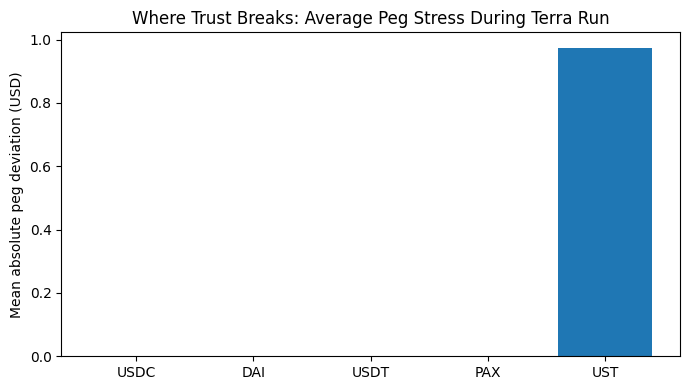

,Asset,Mean |price−1|
1,USDC,0.000021
3,DAI,0.000105
2,USDT,0.000860
4,PAX,0.001014
0,UST,0.974320


In [ ]:
rows = []
for a in ["UST", "USDC", "USDT", "DAI", "PAX"]:
    if a in zoom.columns:
        dev = (zoom[a] - 1.0).abs().dropna()
        if not dev.empty:
            rows.append([a, dev.mean()])

df = pd.DataFrame(rows, columns=["Asset", "Mean |price−1|"]).sort_values("Mean |price−1|")

plt.figure(figsize=(7,4))
plt.bar(df["Asset"], df["Mean |price−1|"])
plt.ylabel("Mean absolute peg deviation (USD)")
plt.title("Where Trust Breaks: Average Peg Stress During Terra Run")
plt.tight_layout()
plt.show()

df



**What the graph shows**
- UST has orders-of-magnitude higher average deviation from $1.
- Other stablecoins show near-zero average stress.

**Interpretation**
- This summarizes the entire episode in one metric.
- Persistent deviation indicates loss of trust, not temporary noise.

**Answer to the question**
- Over the crisis window, **UST uniquely loses trust**.
- Capital concentrates in assets with the smallest peg stress.


## Overall Conclusion

- **Confidence breaks first in UST**, triggering a run.
- **LUNA absorbs the mechanical consequences** and collapses.
- **Capital does not disappear** — it reallocates.
- **Money flows into trusted stablecoins** (USDC, USDT, DAI, PAX), which maintain their peg.
- This mirrors traditional crises: funds flee weak institutions and concentrate in perceived safe assets.

## **Core insight:**  
> Crises do not destroy capital immediately — they *reallocate it toward trust*.

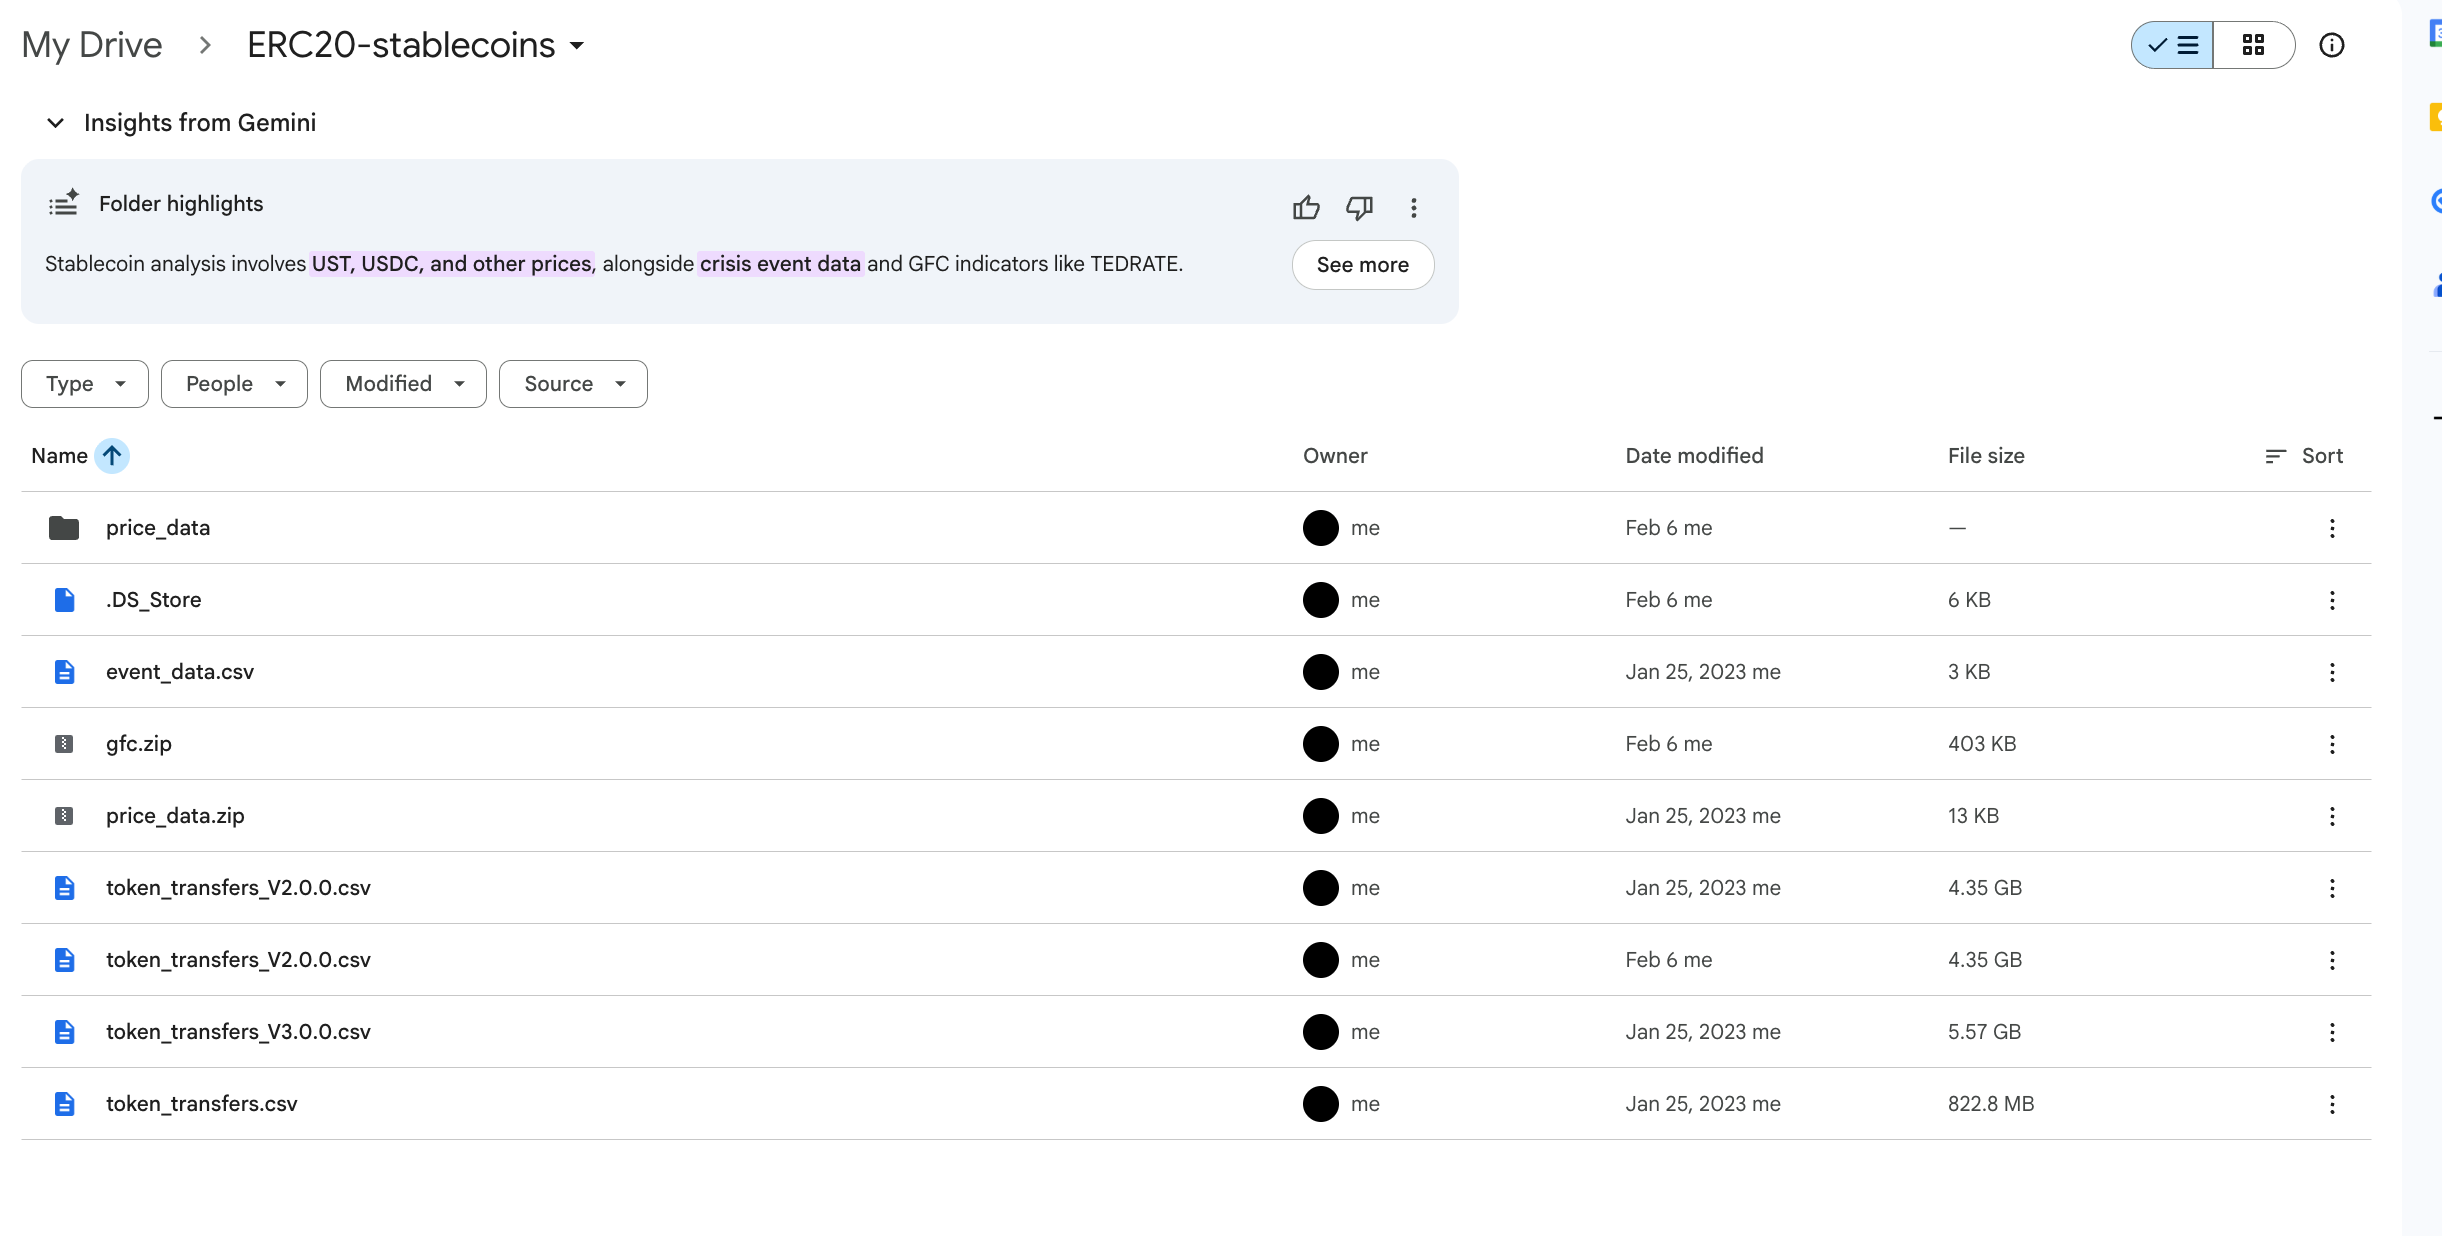

#How to run code- Open a google drive file with all these content inside the file. Next do /content/drive/ however the directory is. For example in the screenshot, it is Mydrive/ER20-stablecoins. Put your version into the BASE_DIR =. The 3 codes below run sequentially,so run the first code, let it generate UST_USDC_filtered.csv into the GOOGLE DRIVE itself. Then repeat for the next code block and the last code block. NOTE: let the code block 21 run for 2 mins max to allow it to read 2 mins worth of data.

In [ ]:
import pandas as pd
import os
import time
from google.colab import drive


print("Refreshing Drive connection...")
drive.mount('/content/drive', force_remount=True)

#Edit source directory here:
BASE_DIR = "/content/drive/MyDrive/ERC20-stablecoins"
SEARCH_NAME = "token_transfers_V2.0.0"
OUTPUT_FILE = os.path.join(BASE_DIR, "UST_USDC_filtered.csv")


TARGET_CONTRACTS = ['0xa47c8bf37f92abed4a126bda807a7b7498661acd', '0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48']
KEEP_COLS = ['time_stamp', 'from_address', 'to_address', 'value', 'contract_address']

def wait_and_process():
    print(f"📡 Monitoring folder: {BASE_DIR}")

    while True:
        if os.path.exists(BASE_DIR):
            files = os.listdir(BASE_DIR)
            target_file = next((f for f in files if SEARCH_NAME in f), None)

            if target_file:
                print(f"FOUND: {target_file}! Starting processing now...")
                input_path = os.path.join(BASE_DIR, target_file)
                process_data(input_path)
                break
            else:
                print(f"File not visible yet. (Colab sees: {files})")
        else:
            print("Folder path not found. Please check your Drive folder names.")

        time.sleep(30)

def process_data(input_path):
    first_chunk = True
    reader = pd.read_csv(input_path, chunksize=100000, usecols=KEEP_COLS)
    chunk_count = 0
    total_rows_processed = 0
    start_time = time.time() # Record start time
    time_limit_seconds = 120 # 2 minutes

    for chunk in reader:
        elapsed_time = time.time() - start_time
        if elapsed_time > time_limit_seconds:
            print(f"Stopping processing after {time_limit_seconds / 60:.0f} minutes. Processed {total_rows_processed} rows.")
            break

        chunk_count += 1
        total_rows_processed += len(chunk)
        print(f"Processing chunk {chunk_count}... Total rows read: {total_rows_processed} (Elapsed: {elapsed_time:.1f}s)")

        filtered = chunk[chunk['contract_address'].isin(TARGET_CONTRACTS)].copy()
        if not filtered.empty:
            try:
                filtered['time_stamp'] = pd.to_datetime(filtered['time_stamp'], unit='s', errors='coerce')
                filtered.dropna(subset=['time_stamp'], inplace=True) # Drop rows where date parsing failed
            except Exception as e:
                print(f"Warning: Error converting time_stamp in chunk {chunk_count}: {e}")
                continue # Skip writing this chunk if datetime conversion fails badly

            mode = 'w' if first_chunk else 'a'
            header = first_chunk
            filtered.to_csv(OUTPUT_FILE, mode=mode, header=header, index=False)
            first_chunk = False

    if not os.path.exists(OUTPUT_FILE) or os.stat(OUTPUT_FILE).st_size == 0:
        print(f"WARNING: Output file {OUTPUT_FILE} was not created or is empty. This might mean no target contracts were found or an error occurred.")
    else:
        print(f"ALL DONE! Your results are in: {OUTPUT_FILE}")

wait_and_process()


Refreshing Drive connection...


MessageError: Error: credential propagation was unsuccessful

In [ ]:
import pandas as pd
import zipfile
import io
import os
import numpy as np

try:
    from google.colab import drive


    drive.mount('/content/drive', force_remount=True)
    #Edit source directory here:
    BASE_DIR = "/content/drive/MyDrive/ERC20-stablecoins"
except ImportError:
    print("Environment: Local MacBook detected.")
    BASE_DIR = "/content/drive/MyDrive/ERC20-stablecoins"

# File Paths based on your Drive/Desktop structure
INPUT_LARGE_CSV = os.path.join(BASE_DIR, "token_transfers_V2.0.0.csv")
ZIP_ERC20 = os.path.join(BASE_DIR, "ERC20-stablecoins.zip")
ZIP_GFC = os.path.join(BASE_DIR, "gfc.zip")
FILE_TRANSFERS = os.path.join(BASE_DIR, "UST_USDC_filtered.csv")
OUTPUT_FILE = os.path.join(BASE_DIR, "Final_Crisis_Comparison.csv")


DATE_LEHMAN = pd.Timestamp('2008-09-15')
DATE_UST = pd.Timestamp('2022-05-09')

def run_extraction_if_needed():
    if os.path.exists(FILE_TRANSFERS):
        print(f"Filtered file already exists: {FILE_TRANSFERS}. Skipping Step 1.")
        return

    print(f"Step 1: Filtering large transactions from {os.path.basename(INPUT_LARGE_CSV)}...")
    if not os.path.exists(INPUT_LARGE_CSV):
        print(f"ERROR: Large CSV not found at {INPUT_LARGE_CSV}. Ensure it's fully synced/uploaded.")
        return

    TARGET_CONTRACTS = [
        '0xa47c8bf37f92abed4a126bda807a7b7498661acd', # USTC
        '0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48'  # USDC
    ]
    KEEP_COLS = ['time_stamp', 'from_address', 'to_address', 'value', 'contract_address']

    first_chunk = True
    reader = pd.read_csv(INPUT_LARGE_CSV, chunksize=100000, usecols=KEEP_COLS)

    for chunk in reader:
        filtered_chunk = chunk[chunk['contract_address'].isin(TARGET_CONTRACTS)].copy()
        if not filtered_chunk.empty:
            filtered_chunk['time_stamp'] = pd.to_datetime(filtered_chunk['time_stamp'], unit='s')
            mode = 'w' if first_chunk else 'a'
            filtered_chunk.to_csv(FILE_TRANSFERS, mode=mode, header=first_chunk, index=False)
            first_chunk = False

def run_alignment():
    print("Step 2: Starting Crisis Alignment...")

    #Load 2022 price data
    ust_daily_price = pd.Series(dtype=float)
    try:
        if os.path.exists(ZIP_ERC20):
            with zipfile.ZipFile(ZIP_ERC20, "r") as z:
                # Handling potential nested zip files
                price_files = [f for f in z.namelist() if "ustc_price_data.csv" in f and "__MACOSX" not in f]
                f_obj = z.open(price_files[0]) if price_files else None

                if not f_obj and "price_data.zip" in z.namelist():
                    nested_zip_data = z.read("price_data.zip")
                    with zipfile.ZipFile(io.BytesIO(nested_zip_data), "r") as nested_z:
                        nested_files = [f for f in nested_z.namelist() if "ustc_price_data.csv" in f]
                        if nested_files: f_obj = nested_z.open(nested_files[0])

                if f_obj:
                    ust_df = pd.read_csv(f_obj)
                    ust_df['timestamp'] = pd.to_datetime(ust_df['timestamp'], unit='s')
                    ust_daily_price = ust_df.set_index('timestamp')['close'].resample('D').mean()
    except Exception as e: print(f"Price Error: {e}")

    #Load gfc data
    gfc_data = {}
    try:
        if os.path.exists(ZIP_GFC):
            with zipfile.ZipFile(ZIP_GFC, "r") as z:
                targets = {'TEDRATE': 'TEDRATE.csv', 'VIX': '^VIX.csv', 'Citigroup': 'C.csv'}
                for key, fname in targets.items():
                    matches = [f for f in z.namelist() if fname in f and "__MACOSX" not in f]
                    if matches:
                        with z.open(matches[0]) as f:
                            df = pd.read_csv(f)
                            val = df.iloc[:, 4] if ("VIX" in fname or "C.csv" in fname) else df.iloc[:, 1]
                            gfc_data[key] = pd.Series(pd.to_numeric(val, errors='coerce').values,
                                                     index=pd.to_datetime(df.iloc[:, 0])).dropna()
    except Exception as e: print(f"GFC Error: {e}")

    #Merge & Normalize
    df_2022 = pd.DataFrame({'UST_Price': ust_daily_price}).dropna()
    if os.path.exists(FILE_TRANSFERS):
        vol_df = pd.read_csv(FILE_TRANSFERS)
        vol_df['time_stamp'] = pd.to_datetime(vol_df['time_stamp'])
        df_2022['Whale_Volume'] = vol_df[vol_df['value'] > 100000].set_index('time_stamp').resample('D')['value'].sum()

    df_2008 = pd.DataFrame(gfc_data).dropna()

    if not df_2008.empty and not df_2022.empty:
        df_2008['days_from_crisis'] = (df_2008.index - DATE_LEHMAN).days
        df_2022['days_from_crisis'] = (df_2022.index - DATE_UST).days

        final_df = pd.merge(df_2008, df_2022, on='days_from_crisis', how='outer').sort_values('days_from_crisis')
        final_df = final_df[(final_df['days_from_crisis'] >= -30) & (final_df['days_from_crisis'] <= 30)]

        # Stress Index (Stress increases as price falls)
        if 'UST_Price' in final_df.columns:
            final_df['UST_Stress_Index'] = 1 - final_df['UST_Price']

        final_df = final_df.interpolate(method='linear')

        # Min-Max Scaling for comparison chart
        for col in ['TEDRATE', 'VIX', 'UST_Stress_Index', 'Whale_Volume']:
            if col in final_df.columns:
                final_df[col] = (final_df[col] - final_df[col].min()) / (final_df[col].max() - final_df[col].min())

        final_df.to_csv(OUTPUT_FILE, index=False)
        print(f"SUCCESS! Final file saved to: {OUTPUT_FILE}")

if __name__ == "__main__":
    run_extraction_if_needed()
    run_alignment()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os


try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    #Edit source directory here:
    BASE_DIR = "/content/drive/MyDrive/ERC20-stablecoins"
except ImportError:
    BASE_DIR = "/content/drive/MyDrive/ERC20-stablecoins"

INPUT_FILE = os.path.join(BASE_DIR, "Final_Crisis_Comparison.csv")
SAVE_PATH = os.path.join(BASE_DIR, "Combined_Crisis_Analysis.png")

# Load Data
if not os.path.exists(INPUT_FILE):
    print(f"ERROR: {INPUT_FILE} not found. Run the alignment script first!")
else:
    df = pd.read_csv(INPUT_FILE)

    # Setup Styles
    plt.style.use('ggplot')
    COLORS = {'DeFi': '#d62728', 'TradFi': '#1f77b4', 'Whale': '#2ca02c'}

if not os.path.exists(INPUT_FILE):
    print(f"FILE MISSING: Cannot find {INPUT_FILE}")
else:
    df = pd.read_csv(INPUT_FILE)

    print("--- CSV Data Health Check ---")
    print(f"Total Rows: {len(df)}")

    # Check the columns needed for the Red Lines
    cols_to_check = ['UST_Stress_Index', 'TEDRATE', 'VIX']

    for col in cols_to_check:
        if col in df.columns:
            non_null = df[col].count()
            pct = (non_null / len(df)) * 100
            print(f"Column '{col}': {non_null} values found ({pct:.1f}% complete)")
        else:
            print(f"Column '{col}': MISSING from CSV!")

    print("\n--- First 5 Rows of Data ---")
    # Displaying the columns relevant to the red lines
    display_cols = ['days_from_crisis'] + [c for c in cols_to_check if c in df.columns]
    print(df[display_cols].head())

    # Alert if data is empty
    if df['UST_Stress_Index'].count() == 0:
        print("\n WARNING: Your UST Stress Index is empty. This is why you don't see red lines.")
        print("This usually means the Price Data zip was not read correctly in the previous step.")

    # ==========================================
    # 2. COMBINED PLOTTING (Subplots)
    # ==========================================
    # Create a figure with 2 rows and 1 column
    fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(12, 12))
    plt.subplots_adjust(hspace=0.3) # Space between the two charts

    # --- TOP CHART: THE ONSET ---
    subset_top = df[(df['days_from_crisis'] >= -20) & (df['days_from_crisis'] <= 10)]
    ax_top.plot(subset_top['days_from_crisis'], subset_top['TEDRATE'],
                label='2008: TED Spread (Credit Freeze)', color=COLORS['TradFi'], linewidth=3)
    ax_top.plot(subset_top['days_from_crisis'], subset_top['UST_Stress_Index'],
                label='2022: UST Depeg (Liquidity Freeze)', color=COLORS['DeFi'], linewidth=3, linestyle='--')
    ax_top.axvline(x=0, color='black', alpha=0.5, linestyle=':', label='Crisis Event (t=0)')
    ax_top.set_title("The Velocity of Panic: 2008 vs 2022", fontsize=16, fontweight='bold')
    ax_top.set_ylabel("Normalized Stress Index (0-1)", fontsize=12)
    ax_top.legend(loc='upper left')

    # --- BOTTOM CHART: CAPITAL FLIGHT ---
    subset_bottom = df[(df['days_from_crisis'] >= -5) & (df['days_from_crisis'] <= 5)]
    # Bar Chart: Whale Volume
    ax_bottom.bar(subset_bottom['days_from_crisis'], subset_bottom['Whale_Volume'],
                  color=COLORS['Whale'], alpha=0.4, label='Whale Outflow Volume')
    ax_bottom.set_ylabel("Whale Outflow Volume", color=COLORS['Whale'], fontsize=12)
    ax_bottom.tick_params(axis='y', labelcolor=COLORS['Whale'])

    # Secondary Axis for Price Stress
    ax_twin = ax_bottom.twinx()
    ax_twin.plot(subset_bottom['days_from_crisis'], subset_bottom['UST_Stress_Index'],
                 color=COLORS['DeFi'], linewidth=4, label='Peg Stress (Inverted Price)')
    ax_twin.set_ylabel("Peg Stress Index", color=COLORS['DeFi'], fontsize=12)
    ax_twin.tick_params(axis='y', labelcolor=COLORS['DeFi'])

    ax_bottom.set_title("Smart Money Exit: Whales Moved Before the Depeg", fontsize=16, fontweight='bold')
    ax_bottom.set_xlabel("Days Relative to Crisis (t=0)", fontsize=12)

    # Combined Legend for Bottom Chart
    lines1, labels1 = ax_bottom.get_legend_handles_labels()
    lines2, labels2 = ax_twin.get_legend_handles_labels()
    ax_bottom.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    # ==========================================
    # 3. SAVE & EXPORT
    # ==========================================
    plt.savefig(SAVE_PATH, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n Dashboard generated and saved to: {SAVE_PATH}")
